# Experiment 09 — PFA Knowledge Tracing Comparison

Compares three KC models using Performance Factor Analysis (PFA) on CodeWorkout.
PFA is logistic regression: P(correct) = 1/(1+e^(-m)) where m = Σ(β + γ×successes + ρ×failures) per KC.
Better KC mappings → better prediction → higher AUC.

- **Run 1**: KCGen-KT's LLM-generated KCs (11 KCs from GPT-4o)
- **Run 2**: Instructor KCs (18 KCs from problem_prompts.csv)
- **Run 3**: Our enhanced KCs (instructor + LLM refined) — placeholder for now

In [11]:
import pandas as pd
import numpy as np
import json
import os
from collections import defaultdict
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

N_FOLDS = 5
RANDOM_SEED = 42

print("=" * 70)
print("Experiment 09 — PFA Knowledge Tracing Comparison")
print("=" * 70)

Experiment 09 — PFA Knowledge Tracing Comparison


## Load and prepare data
- Filter to Run.Program events (these have scores)
- Binarize: Score == 1.0 → correct, else incorrect (standard in Code-DKT, TIKTOC, KCGen-KT)
- Keep first attempt per student per problem only
- Sort by student + timestamp (order matters for PFA)

In [12]:
mt = pd.read_csv("dataset/CodeWorkout/MainTable.csv")
print(f"Raw MainTable: {len(mt)} rows, {mt['SubjectID'].nunique()} students, {mt['ProblemID'].nunique()} problems")

# Keep only Run.Program events with scores
mt = mt[mt['EventType'] == 'Run.Program'].copy()
mt = mt.dropna(subset=['Score'])

# Sort by student and timestamp
mt['ServerTimestamp'] = pd.to_datetime(mt['ServerTimestamp'])
mt.sort_values(['SubjectID', 'ServerTimestamp'], inplace=True)

# Binarize: 1.0 = correct (all test cases pass), else incorrect
mt['correct'] = (mt['Score'] == 1.0).astype(int)

# First attempt per student per problem only
first_attempts = mt.drop_duplicates(subset=['SubjectID', 'ProblemID'], keep='first').copy()
first_attempts = first_attempts.reset_index(drop=True)

print(f"First attempts: {len(first_attempts)} rows, {first_attempts['SubjectID'].nunique()} students, {first_attempts['ProblemID'].nunique()} problems")
print(f"Correct rate: {first_attempts['correct'].mean():.3f}")

Raw MainTable: 201570 rows, 413 students, 50 problems
First attempts: 16179 rows, 413 students, 50 problems
Correct rate: 0.403


## Load three KC models

**KC Model 1 — KCGen-KT LLM**: from problem_kc.json (GPT-4o generated, 11 clustered KCs)  
**KC Model 2 — Instructor**: from problem_prompts.csv (18 human-written KCs)  
**KC Model 3 — Enhanced**: placeholder using instructor KCs (will replace with LLM-refined later)

In [13]:
pp = pd.read_csv("dataset/CodeWorkout/Problem_Prompts/problem_prompts.csv")
kc_cols = list(pp.columns)[3:]  # 18 KC columns

# Build Requirement text -> ProblemID lookup
requirement_to_pid = dict(zip(pp['Requirement'], pp['ProblemID']))

# --- KC Model 1: KCGen-KT LLM-generated KCs ---
with open("dataset/kcgen-kt/problem_kc.json") as f:
    kcgen_raw = json.load(f)

kcgen_kc_map = {}  # ProblemID -> [kc_name, ...]
unmatched = 0

for req_text, kc_list in kcgen_raw.items():
    # Match to ProblemID — try exact match first
    pid = requirement_to_pid.get(req_text)
    
    # Fallback: match first 100 chars
    if pid is None:
        for req, p in requirement_to_pid.items():
            if req[:100] == req_text[:100]:
                pid = p
                break
    
    if pid is not None:
        kc_names = []
        for item in kc_list:
            if isinstance(item, list) and len(item) >= 2:
                kc_names.append(item[1])  # [reasoning, kc_name]
            elif isinstance(item, str):
                kc_names.append(item)
        kcgen_kc_map[pid] = list(set(kc_names))
    else:
        unmatched += 1

kcgen_all_kcs = sorted(set(kc for kcs in kcgen_kc_map.values() for kc in kcs))
print(f"KC Model 1 (KCGen-KT LLM): {len(kcgen_all_kcs)} unique KCs, {len(kcgen_kc_map)} problems mapped, {unmatched} unmatched")

# --- KC Model 2: Instructor KCs ---
instructor_kc_map = {}  # ProblemID -> [kc_name, ...]
for _, row in pp.iterrows():
    pid = row['ProblemID']
    kcs = [kc_cols[i] for i, v in enumerate(row[3:]) if v == 1]
    instructor_kc_map[pid] = kcs

instructor_all_kcs = sorted(kc_cols)
print(f"\nKC Model 2 (Instructor): {len(instructor_all_kcs)} unique KCs, {len(instructor_all_kcs)} KCs registered, {len(instructor_kc_map)} problems mapped")

# --- KC Model 3: Enhanced KCs (Refined via LLM + Student Samples) ---
MAPPING_FILE = "run3_kc_mapping.json"
if os.path.exists(MAPPING_FILE):
    with open(MAPPING_FILE, 'r') as f:
        raw_mapping = json.load(f)
        # Final cleanup: convert problem IDs to int and strings to lists
        enhanced_kc_map = {}
        for k, v in raw_mapping.items():
            if k.isdigit():
                enhanced_kc_map[int(k)] = v
            elif isinstance(k, (int, float)):
                enhanced_kc_map[int(k)] = v
                
    enhanced_all_kcs = sorted(set(kc for kcs in enhanced_kc_map.values() for kc in kcs))
    print(f"\nKC Model 3 (Enhanced): Successfully loaded {len(enhanced_kc_map)} refined problem mappings from {MAPPING_FILE}.")
else:
    print(f"\n⚠️ WARNING: {MAPPING_FILE} not found. Ensure it was generated by Experiment 10.")
    enhanced_kc_map = instructor_kc_map.copy()
    enhanced_all_kcs = instructor_all_kcs.copy()

KC Model 1 (KCGen-KT LLM): 11 unique KCs, 50 problems mapped, 0 unmatched

KC Model 2 (Instructor): 18 unique KCs, 18 KCs registered, 50 problems mapped

KC Model 3 (Enhanced): Successfully loaded 50 refined problem mappings from run3_kc_mapping.json.


## Build PFA features

For each student-problem submission (chronological order):
1. Look up which KCs this problem requires
2. Get student's **prior** success/failure counts for those KCs
3. Create feature vector: [success_kc1, failure_kc1, success_kc2, failure_kc2, ...]
4. Record label (correct/incorrect)
5. **Then** update running counts

Key: features capture state BEFORE the attempt. Counts update AFTER.

In [14]:
def build_pfa_features(submissions_df, kc_map, all_kcs):
    """Build PFA features: prior success/failure counts per KC for each submission."""
    kc_to_idx = {kc: i for i, kc in enumerate(all_kcs)}
    n_kcs = len(all_kcs)
    
    X_rows = []
    y_rows = []
    student_ids = []
    skipped = 0
    
    for student_id, student_df in submissions_df.groupby('SubjectID'):
        # Running counts for this student
        success_counts = np.zeros(n_kcs)
        failure_counts = np.zeros(n_kcs)
        
        for _, row in student_df.iterrows():
            pid = row['ProblemID']
            correct = row['correct']
            
            if pid not in kc_map or len(kc_map[pid]) == 0:
                skipped += 1
                continue
            
            problem_kcs = kc_map[pid]
            
            # FEATURES: prior counts (BEFORE this attempt)
            feature_vec = np.zeros(2 * n_kcs)
            for kc in problem_kcs:
                if kc in kc_to_idx:
                    idx = kc_to_idx[kc]
                    feature_vec[2 * idx] = success_counts[idx]
                    feature_vec[2 * idx + 1] = failure_counts[idx]
            
            X_rows.append(feature_vec)
            y_rows.append(correct)
            student_ids.append(student_id)
            
            # UPDATE: after this attempt
            for kc in problem_kcs:
                if kc in kc_to_idx:
                    idx = kc_to_idx[kc]
                    if correct == 1:
                        success_counts[idx] += 1
                    else:
                        failure_counts[idx] += 1
    
    if skipped > 0:
        print(f"  Skipped {skipped} submissions (no KC mapping)")
    
    return np.array(X_rows), np.array(y_rows), student_ids

print("Building PFA features...")

print(f"\nKC Model 1 (KCGen-KT LLM, {len(kcgen_all_kcs)} KCs):")
X1, y1, sids1 = build_pfa_features(first_attempts, kcgen_kc_map, kcgen_all_kcs)
print(f"  X shape: {X1.shape} ({len(kcgen_all_kcs)} KCs × 2 = {2*len(kcgen_all_kcs)} features)")

print(f"\nKC Model 2 (Instructor, {len(instructor_all_kcs)} KCs):")
X2, y2, sids2 = build_pfa_features(first_attempts, instructor_kc_map, instructor_all_kcs)
print(f"  X shape: {X2.shape} ({len(instructor_all_kcs)} KCs × 2 = {2*len(instructor_all_kcs)} features)")

print(f"\nKC Model 3 (Enhanced, {len(enhanced_all_kcs)} KCs):")
X3, y3, sids3 = build_pfa_features(first_attempts, enhanced_kc_map, enhanced_all_kcs)
print(f"  X shape: {X3.shape} ({len(enhanced_all_kcs)} KCs × 2 = {2*len(enhanced_all_kcs)} features)")

Building PFA features...

KC Model 1 (KCGen-KT LLM, 11 KCs):
  X shape: (16179, 22) (11 KCs × 2 = 22 features)

KC Model 2 (Instructor, 18 KCs):
  X shape: (16179, 36) (18 KCs × 2 = 36 features)

KC Model 3 (Enhanced, 17 KCs):
  X shape: (16179, 34) (17 KCs × 2 = 34 features)


## Run PFA with 5-fold cross-validation

Split by **students** (not submissions) to prevent data leakage.  
All of a student's submissions go to either train or test, never split.

In [15]:
def run_pfa_cv(X, y, student_ids, n_folds=5, seed=42):
    """Run PFA (logistic regression) with student-level stratified K-fold CV."""
    unique_students = list(set(student_ids))
    sid_array = np.array(student_ids)
    
    # Student-level labels for stratification
    student_avg = {}
    for s in unique_students:
        mask = sid_array == s
        student_avg[s] = y[mask].mean()
    student_labels = np.array([1 if student_avg[s] >= 0.5 else 0 for s in unique_students])
    
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    aucs, f1s, accs = [], [], []
    
    for fold, (train_idx, test_idx) in enumerate(skf.split(unique_students, student_labels), 1):
        train_students = set(np.array(unique_students)[train_idx])
        test_students = set(np.array(unique_students)[test_idx])
        
        train_mask = np.array([s in train_students for s in student_ids])
        test_mask = np.array([s in test_students for s in student_ids])
        
        X_train, y_train = X[train_mask], y[train_mask]
        X_test, y_test = X[test_mask], y[test_mask]
        
        model = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=seed)
        model.fit(X_train, y_train)
        
        y_prob = model.predict_proba(X_test)[:, 1]
        y_pred = model.predict(X_test)
        
        auc = roc_auc_score(y_test, y_prob)
        f1 = f1_score(y_test, y_pred)
        acc = accuracy_score(y_test, y_pred)
        
        aucs.append(auc)
        f1s.append(f1)
        accs.append(acc)
        print(f"  Fold {fold}: AUC={auc:.4f}, F1={f1:.4f}, Acc={acc:.4f}")
    
    return {
        'AUC': (np.mean(aucs), np.std(aucs)),
        'F1': (np.mean(f1s), np.std(f1s)),
        'Accuracy': (np.mean(accs), np.std(accs)),
        'per_fold_auc': aucs,
    }

print("=" * 70)
print("Running PFA Cross-Validation")
print("=" * 70)

print(f"\n--- Run 1: KCGen-KT LLM KCs ({len(kcgen_all_kcs)} KCs) ---")
results_1 = run_pfa_cv(X1, y1, sids1, N_FOLDS, RANDOM_SEED)

print(f"\n--- Run 2: Instructor KCs ({len(instructor_all_kcs)} KCs) ---")
results_2 = run_pfa_cv(X2, y2, sids2, N_FOLDS, RANDOM_SEED)

print(f"\n--- Run 3: Enhanced KCs ({len(enhanced_all_kcs)} KCs) ---")
results_3 = run_pfa_cv(X3, y3, sids3, N_FOLDS, RANDOM_SEED)

Running PFA Cross-Validation

--- Run 1: KCGen-KT LLM KCs (11 KCs) ---
  Fold 1: AUC=0.7596, F1=0.5615, Acc=0.7078
  Fold 2: AUC=0.7626, F1=0.5386, Acc=0.7163
  Fold 3: AUC=0.7652, F1=0.5603, Acc=0.7132
  Fold 4: AUC=0.7438, F1=0.5487, Acc=0.6997
  Fold 5: AUC=0.7553, F1=0.5527, Acc=0.7092

--- Run 2: Instructor KCs (18 KCs) ---
  Fold 1: AUC=0.7805, F1=0.5923, Acc=0.7224
  Fold 2: AUC=0.7795, F1=0.5889, Acc=0.7344
  Fold 3: AUC=0.7744, F1=0.5862, Acc=0.7192
  Fold 4: AUC=0.7623, F1=0.5818, Acc=0.7097
  Fold 5: AUC=0.7720, F1=0.5903, Acc=0.7217

--- Run 3: Enhanced KCs (17 KCs) ---
  Fold 1: AUC=0.7621, F1=0.5683, Acc=0.7085
  Fold 2: AUC=0.7696, F1=0.5830, Acc=0.7300
  Fold 3: AUC=0.7755, F1=0.5934, Acc=0.7234
  Fold 4: AUC=0.7524, F1=0.5866, Acc=0.7124
  Fold 5: AUC=0.7696, F1=0.6061, Acc=0.7288


## Results summary

In [16]:
print("\n" + "=" * 70)
print("RESULTS SUMMARY")
print("=" * 70)

print(f"\n{'KC Model':<35} {'AUC':>14} {'F1':>14} {'Accuracy':>14}")
print("-" * 80)

all_results = [
    (f"KCGen-KT LLM ({len(kcgen_all_kcs)} KCs)", results_1),
    (f"Instructor ({len(instructor_all_kcs)} KCs)", results_2),
    (f"Enhanced ({len(enhanced_all_kcs)} KCs)", results_3),
]

for name, res in all_results:
    auc_m, auc_s = res['AUC']
    f1_m, f1_s = res['F1']
    acc_m, acc_s = res['Accuracy']
    print(f"{name:<35} {auc_m:.4f}±{auc_s:.4f} {f1_m:.4f}±{f1_s:.4f} {acc_m:.4f}±{acc_s:.4f}")

# Save to CSV
results_df = pd.DataFrame([
    {
        'KC_Model': name,
        'Num_KCs': len(kcgen_all_kcs) if 'LLM' in name else len(instructor_all_kcs),
        'AUC_mean': res['AUC'][0], 'AUC_std': res['AUC'][1],
        'F1_mean': res['F1'][0], 'F1_std': res['F1'][1],
        'Acc_mean': res['Accuracy'][0], 'Acc_std': res['Accuracy'][1],
    }
    for name, res in all_results
])
results_df.to_csv('09_pfa_results.csv', index=False)
print("\nSaved to 09_pfa_results.csv")


RESULTS SUMMARY

KC Model                                       AUC             F1       Accuracy
--------------------------------------------------------------------------------
KCGen-KT LLM (11 KCs)               0.7573±0.0075 0.5524±0.0084 0.7092±0.0057
Instructor (18 KCs)                 0.7737±0.0065 0.5879±0.0037 0.7215±0.0079
Enhanced (17 KCs)                   0.7658±0.0079 0.5875±0.0124 0.7206±0.0087

Saved to 09_pfa_results.csv


## Statistical significance
Paired t-test on per-fold AUC values between each pair of runs.

In [17]:
print("\n--- Statistical Significance (paired t-test on per-fold AUC) ---\n")

comparisons = [
    ("KCGen-KT LLM", results_1, "Instructor", results_2),
    ("Instructor", results_2, "Enhanced", results_3),
    ("KCGen-KT LLM", results_1, "Enhanced", results_3),
]

for name_a, res_a, name_b, res_b in comparisons:
    t_stat, p_val = stats.ttest_rel(res_a['per_fold_auc'], res_b['per_fold_auc'])
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
    delta = np.mean(res_a['per_fold_auc']) - np.mean(res_b['per_fold_auc'])
    print(f"  {name_a} vs {name_b}:")
    print(f"    ΔAUC = {delta:+.4f}, t = {t_stat:.3f}, p = {p_val:.4f} [{sig}]")
    print()


--- Statistical Significance (paired t-test on per-fold AUC) ---

  KCGen-KT LLM vs Instructor:
    ΔAUC = -0.0164, t = -8.376, p = 0.0011 [**]

  Instructor vs Enhanced:
    ΔAUC = +0.0079, t = 2.351, p = 0.0784 [ns]

  KCGen-KT LLM vs Enhanced:
    ΔAUC = -0.0085, t = -4.453, p = 0.0112 [*]



## Visualization — AUC / F1 / Accuracy bar chart

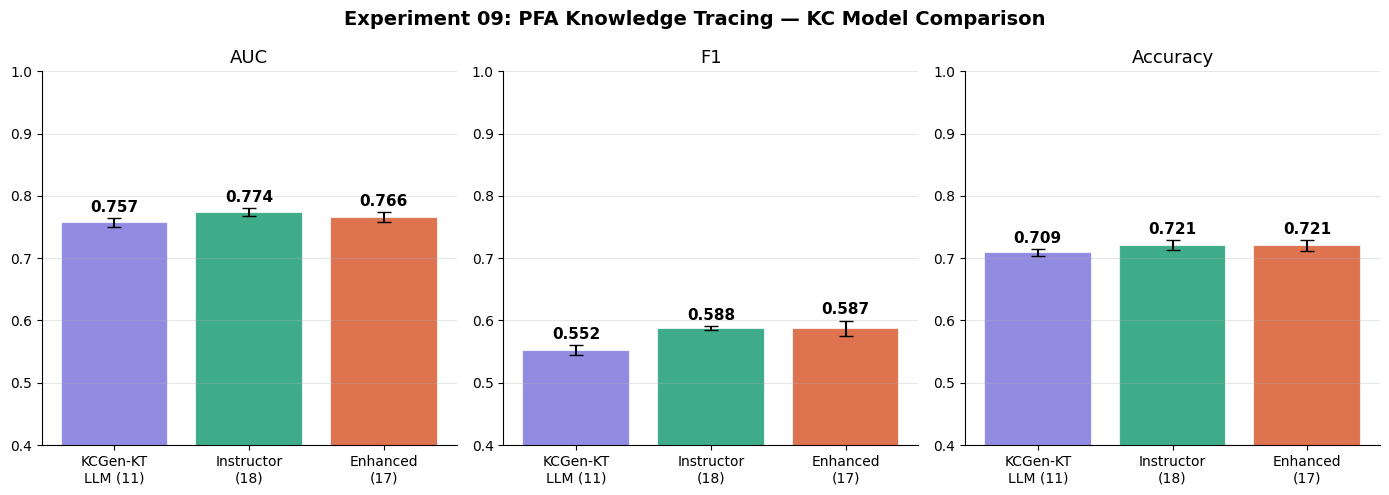

Saved: 09_pfa_comparison_results.png


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Experiment 09: PFA Knowledge Tracing — KC Model Comparison',
             fontsize=14, fontweight='bold')

metrics = ['AUC', 'F1', 'Accuracy']
model_names = [
    f'KCGen-KT\nLLM ({len(kcgen_all_kcs)})',
    f'Instructor\n({len(instructor_all_kcs)})',
    f'Enhanced\n({len(enhanced_all_kcs)})'
]
colors = ['#7F77DD', '#1D9E75', '#D85A30']
result_list = [results_1, results_2, results_3]

for ax, metric in zip(axes, metrics):
    means = [r[metric][0] for r in result_list]
    stds = [r[metric][1] for r in result_list]
    
    bars = ax.bar(model_names, means, yerr=stds, capsize=5,
                  color=colors, alpha=0.85, edgecolor='white', linewidth=1.5)
    
    for bar, mean, std in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.005,
                f'{mean:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    ax.set_title(metric, fontsize=13)
    ax.set_ylim(0.4, 1.0)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('09_pfa_comparison_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 09_pfa_comparison_results.png")

## Learning curves per KC
For each KC: error rate vs practice opportunity.
Good KCs → decreasing curve (students learn). Bad KCs → flat/noisy.

Computing learning curves...


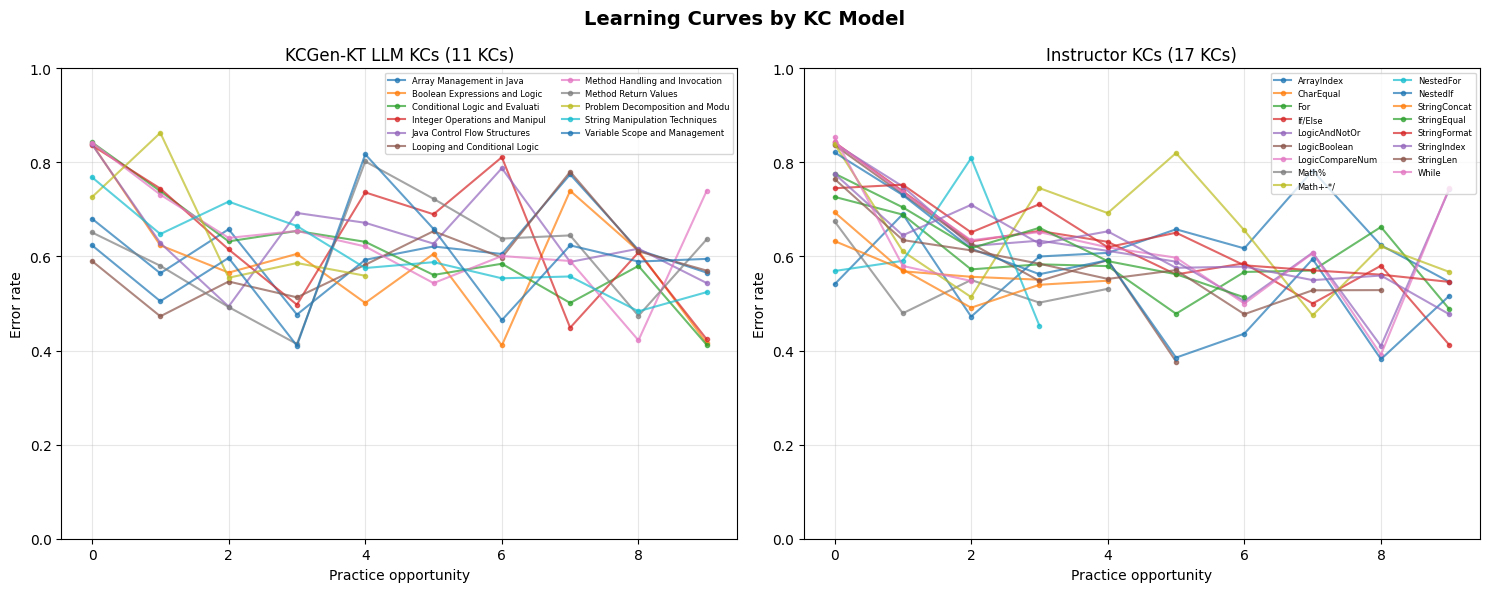

Saved: 09_learning_curves_comparison.png


In [19]:
def compute_learning_curves(submissions_df, kc_map, all_kcs, max_opps=10):
    """Compute error rate at each practice opportunity for each KC."""
    kc_curves = {kc: defaultdict(list) for kc in all_kcs}
    
    for student_id, student_df in submissions_df.groupby('SubjectID'):
        kc_opp = defaultdict(int)
        
        for _, row in student_df.iterrows():
            pid = row['ProblemID']
            correct = row['correct']
            
            if pid not in kc_map:
                continue
            
            for kc in kc_map[pid]:
                if kc in kc_curves:
                    opp = kc_opp[kc]
                    if opp < max_opps:
                        kc_curves[kc][opp].append(1 - correct)  # error rate
                    kc_opp[kc] += 1
    
    result = {}
    for kc, opp_dict in kc_curves.items():
        if len(opp_dict) > 2:
            opps = sorted(opp_dict.keys())
            avg_errors = [np.mean(opp_dict[o]) for o in opps]
            counts = [len(opp_dict[o]) for o in opps]
            result[kc] = {'opportunities': opps, 'error_rates': avg_errors, 'counts': counts}
    
    return result

print("Computing learning curves...")
curves_1 = compute_learning_curves(first_attempts, kcgen_kc_map, kcgen_all_kcs)
curves_2 = compute_learning_curves(first_attempts, instructor_kc_map, instructor_all_kcs)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Learning Curves by KC Model', fontsize=14, fontweight='bold')

ax = axes[0]
ax.set_title(f'KCGen-KT LLM KCs ({len(curves_1)} KCs)', fontsize=12)
for kc, data in sorted(curves_1.items()):
    ax.plot(data['opportunities'], data['error_rates'],
            marker='o', markersize=3, alpha=0.7, label=kc[:30])
ax.set_xlabel('Practice opportunity')
ax.set_ylabel('Error rate')
ax.set_ylim(0, 1)
ax.legend(fontsize=6, ncol=2, loc='upper right')
ax.grid(alpha=0.3)

ax = axes[1]
ax.set_title(f'Instructor KCs ({len(curves_2)} KCs)', fontsize=12)
for kc, data in sorted(curves_2.items()):
    ax.plot(data['opportunities'], data['error_rates'],
            marker='o', markersize=3, alpha=0.7, label=kc[:15])
ax.set_xlabel('Practice opportunity')
ax.set_ylabel('Error rate')
ax.set_ylim(0, 1)
ax.legend(fontsize=6, ncol=2, loc='upper right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('09_learning_curves_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 09_learning_curves_comparison.png")

## Per-KC analysis — learned PFA parameters
Fit one final model on all data to inspect which KCs have the strongest learned weights.

In [20]:
# Fit final model on all data for instructor KCs to inspect parameters
final_model = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=RANDOM_SEED)
final_model.fit(X2, y2)

coefs = final_model.coef_[0]
print("Instructor KC PFA Parameters (learned weights):")
print(f"\n{'KC':<20} {'γ (success)':>12} {'ρ (failure)':>12} {'Interpretation'}")
print("-" * 70)

for i, kc in enumerate(instructor_all_kcs):
    gamma = coefs[2 * i]      # success weight
    rho = coefs[2 * i + 1]    # failure weight
    
    if gamma > 0.1:
        interp = "Practice helps a lot"
    elif gamma > 0:
        interp = "Practice helps slightly"
    elif rho < -0.1:
        interp = "Failures hurt — hard KC"
    else:
        interp = "Weak signal"
    
    print(f"{kc:<20} {gamma:>12.4f} {rho:>12.4f}   {interp}")

print(f"\nIntercept (baseline difficulty): {final_model.intercept_[0]:.4f}")

Instructor KC PFA Parameters (learned weights):

KC                    γ (success)  ρ (failure) Interpretation
----------------------------------------------------------------------
ArrayIndex                 0.0215      -0.0345   Practice helps slightly
CharEqual                  0.0495      -0.0049   Practice helps slightly
DefFunction               -0.6824      -0.4060   Failures hurt — hard KC
For                        0.1245       0.0095   Practice helps a lot
If/Else                    0.0346      -0.0393   Practice helps slightly
LogicAndNotOr             -0.0327      -0.0035   Weak signal
LogicBoolean               0.3880      -0.1007   Practice helps a lot
LogicCompareNum            0.0269      -0.0179   Practice helps slightly
Math%                      0.2023       0.3371   Practice helps a lot
Math+-*/                   0.0566      -0.0179   Practice helps slightly
NestedFor                 -0.5355      -0.1239   Failures hurt — hard KC
NestedIf                   0.2398   

## Done

**Next steps:**
1. Replace `enhanced_kc_map` (Run 3) with LLM-refined KC mapping from your experiments
2. Re-run to get the three-way comparison
3. Report AUC, learning curves, and statistical significance in thesis Chapter 4